# 4. Confounders, specificity and interpretation

Can the result be explained by something other than resting physiology?

| Section | Question |
| --- | --- |
| 4.2 | export format and batch |
| 4.3 | recording quality |
| 4.4 | the T3 and T4 leads |
| 4.5 | age |
| 4.6 | Schulte solve time |
| 4.7–4.8 | feature contributions and false positives |
| 4.10 | shared clinical profile or PTSD-specific feature |
| 4.11 | robustness to an unseen batch and label permutation |

All probabilities are the out-of-fold predictions of protocol 8, and the diagnostic models use the same folds.

In [1]:
import json
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

from model.model import load
from src import confounders, config, dataset, evaluation, models, viz

warnings.filterwarnings("ignore", message="The least populated class")
warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
VALIDATION = ROOT / "results" / "validation" / "protocol8"
P8 = models.PROTOCOL_8

data = models.load_training_data(protocol=P8)
keys = list(data.subject_keys)
oof = pd.read_csv(VALIDATION / "nested_oof.csv", index_col=0).loc[keys]
registry, _, subjects = dataset.scan_dataset(config.DATA_DIR)
final = load(ROOT / "model" / "weights")
stratum, groups = data.stratum, data.groups
ptsd = stratum == models.STRATUM_PTSD
YOUNG = ("control_A", "control_B", "control_C", "control_B_supplement")
SLICES = {
    "controls < 65": YOUNG,
    "controls A, B, suppl.": ("control_A", "control_B", "control_B_supplement"),
    "all format B controls": ("control_B", "control_B_supplement", "control_ageing"),
    **{viz.STRATUM_LABELS[s]: (s,) for s in viz.STRATUM_ORDER[1:]},
}


def auc_slices(p: np.ndarray) -> pd.Series:
    """AUC of PTSD vs each negative slice for scores ``p`` (n_subjects,)."""
    out = {}
    for name, negatives in SLICES.items():
        mask = ptsd | np.isin(stratum, negatives)
        out[name] = roc_auc_score(ptsd[mask], p[mask])
    return pd.Series(out)


model_auc = auc_slices(oof["p_raw"].to_numpy())

## 4.2 Export format and batch

A model trained on export metadata alone shows how much knowing the format is worth. Within format B (controls B, supplementary batch, controls 65+) both classes share the same format.

In [2]:
meta_oof = pd.read_csv(VALIDATION / "metadata_oof.csv", index_col=0).loc[keys]
format_table = pd.DataFrame({"submitted model (OOF)": model_auc, "export metadata only": auc_slices(meta_oof["p"].to_numpy())})
format_table["subjects in slice"] = [int(np.isin(stratum, s).sum()) for s in SLICES.values()]
format_table.rename_axis("AUC of PTSD against")

,submitted model (OOF),export metadata only,subjects in slice
AUC of PTSD against,,,
controls < 65,0.864,0.607,107
"controls A, B, suppl.",0.765,0.323,62
all format B controls,0.839,0.000,65
control A,0.670,1.000,20
control B,0.460,0.000,2
control C,1.000,1.000,45
suppl. controls,0.828,0.000,40
controls 65+,0.890,0.000,23
somatoform,0.792,1.000,74


- Metadata separate PTSD perfectly from controls A and C and from somatoform patients, and not at all from format B controls.
- **Within format B the model still separates PTSD from 65 controls with AUC 0.84**, so this part is not the format.
- Against control C both the model and the metadata reach AUC 1.00, which is not a physiological marker.
- Differences between recording batches within format B cannot be ruled out with these data.

## 4.3 Recording quality

Two diagnostic models: the share of retained windows and copy flags per channel, and the same plus indicators of missing features.

In [3]:
quality = confounders.quality_descriptors(keys)
x_quality = quality.to_numpy(dtype=float)
x_missing = np.isnan(data.tables[final.metadata["feature_set"]]).astype(float)
quality_table = pd.DataFrame({
    "submitted model (OOF)": model_auc,
    "recording quality": auc_slices(confounders.diagnostic_oof(data, x_quality)),
    "quality + missing features": auc_slices(confounders.diagnostic_oof(data, np.hstack([x_quality, x_missing]))),
})
quality_table.rename_axis("AUC of PTSD against")

,submitted model (OOF),recording quality,quality + missing features
AUC of PTSD against,,,
controls < 65,0.864,0.497,0.691
"controls A, B, suppl.",0.765,0.596,0.583
all format B controls,0.839,0.578,0.665
control A,0.670,0.542,0.546
control B,0.460,0.460,0.440
control C,1.000,0.360,0.840
suppl. controls,0.828,0.630,0.609
controls 65+,0.890,0.499,0.781
somatoform,0.792,0.498,0.534


- Quality alone does not separate PTSD from controls under 65.
- Adding missing-feature indicators helps a little, through control C and older adults without an alpha peak. In the model a missing value is replaced by the median, so this route contributes almost nothing.

## 4.4 The T3 and T4 leads

T3 sits next to the reference and depends most on recording conditions. Two checks: replacing the T3 (or T3 and T4) features with the median at test time only, and retraining without T3 and T4.

In [4]:
t3 = [n for n in data.feature_names["rest_O1FpT_exp"] if n.endswith("_T3")]
t34 = [n for n in data.feature_names["rest_O1FpT_exp"] if n.endswith(("_T3", "_T4"))]
runs = {
    "submitted model": oof,
    "T3 set to median at test": evaluation.nested_oof(data, P8, mask_at_test=t3),
    "T3, T4 set to median at test": evaluation.nested_oof(data, P8, mask_at_test=t34),
    "retrained without T3/T4": evaluation.nested_oof(data, models.restricted_protocol(P8, ["rest_O1Fp", "rest_O1Fp_exp"], "protocol8_no_T")),
}
t_table = pd.DataFrame({name: auc_slices(r["p_raw"].to_numpy()) for name, r in runs.items()}).T
t_table["sensitivity at 0.5"] = [np.mean(r["p"].to_numpy()[ptsd] >= 0.5) for r in runs.values()]
t_table["specificity 65+ and somatoform"] = [
    np.mean(r["p"].to_numpy()[np.isin(stratum, ["control_ageing", "somatoform"])] < 0.5) for r in runs.values()]
t_table[["controls < 65", "controls A, B, suppl.", "control A", "suppl. controls", "controls 65+", "somatoform",
         "sensitivity at 0.5", "specificity 65+ and somatoform"]]

,controls < 65,"controls A, B, suppl.",control A,suppl. controls,controls 65+,somatoform,sensitivity at 0.5,specificity 65+ and somatoform
submitted model,0.864,0.765,0.670,0.828,0.890,0.792,0.84,0.670
T3 set to median at test,0.721,0.681,0.644,0.708,0.828,0.668,0.32,0.897
"T3, T4 set to median at test",0.693,0.615,0.612,0.623,0.837,0.638,0.16,0.938
retrained without T3/T4,0.720,0.572,0.544,0.597,0.897,0.658,0.64,0.691


- Replacing T3 with the median lowers the AUC against controls under 65 noticeably.
- **Without T3 and T4 the separation from young controls A and B almost disappears**, while separation from older adults remains.
- Separation of PTSD from young controls relies on the temporal leads, where physiology and batch cannot be told apart. This is the main limitation of the model.

## 4.5 Age

Can age be predicted from the same features within the controls? Ridge regression with leave-one-group-out; R² at or below zero means the features know nothing about age beyond the mean.

In [5]:
x_model = data.tables[final.metadata["feature_set"]]
age = subjects.loc[keys, "age"].to_numpy(dtype=float)
age_sets = {
    "controls < 65, all formats": np.isin(stratum, YOUNG),
    "controls < 65 without format C": np.isin(stratum, ("control_A", "control_B", "control_B_supplement")),
    "supplementary batch only (17–41 years)": stratum == "control_B_supplement",
    "all controls including 65+": np.isin(stratum, (*YOUNG, "control_ageing")),
}
age_rows, age_pred = {}, {}
for name, m in age_sets.items():
    pred, ref = confounders.age_prediction_oof(x_model[m], age[m], groups[m])
    age_pred[name] = pred
    age_rows[name] = {
        "controls": int(m.sum()),
        "R² out of sample": 1 - np.sum((pred - age[m]) ** 2) / np.sum((ref - age[m]) ** 2),
        "MAE of the model, years": np.mean(np.abs(pred - age[m])),
        "MAE of the mean, years": np.mean(np.abs(ref - age[m])),
    }
pd.DataFrame(age_rows).T

,controls,R² out of sample,"MAE of the model, years","MAE of the mean, years"
"controls < 65, all formats",107.0,0.150,8.502,9.769
controls < 65 without format C,62.0,-0.029,6.615,6.640
supplementary batch only (17–41 years),40.0,-0.383,5.650,5.053
all controls including 65+,130.0,0.287,12.552,15.553


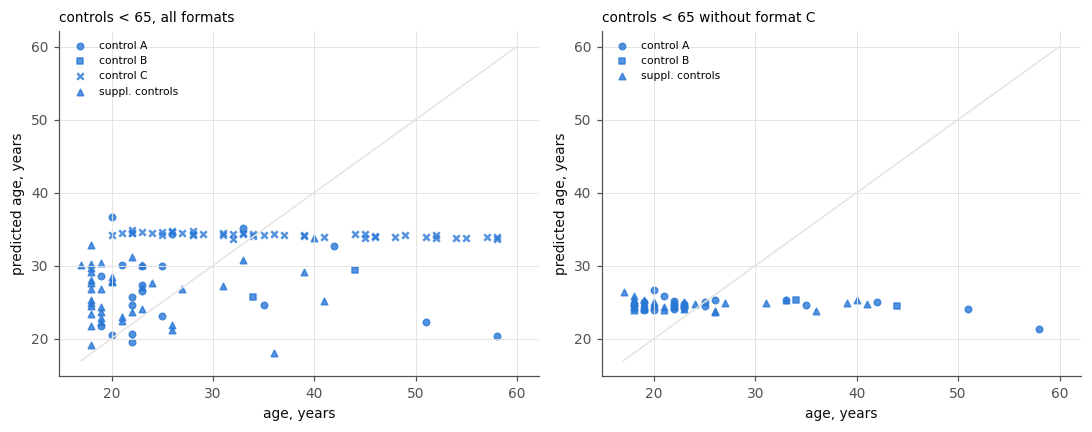

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
for ax, name in zip(axes, ["controls < 65, all formats", "controls < 65 without format C"]):
    m = age_sets[name]
    for s, marker in [("control_A", "o"), ("control_B", "s"), ("control_C", "x"), ("control_B_supplement", "^")]:
        sel = stratum[m] == s
        if sel.any():
            ax.scatter(age[m][sel], age_pred[name][sel], marker=marker, s=18, color=viz.COHORT_COLORS[config.GROUP_CONTROL],
                       alpha=0.8, label=viz.STRATUM_LABELS[s])
    ax.plot([17, 60], [17, 60], color=viz.GRID, lw=1)
    ax.set_xlabel("age, years")
    ax.set_ylabel("predicted age, years")
    ax.set_title(name, loc="left", fontsize=9)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**P against age within batches** (Spearman rank correlation):

In [7]:
corr_rows = {}
for name, negatives in {"controls < 65, all formats": YOUNG, **{viz.STRATUM_LABELS[s]: (s,) for s in ("control_A", "control_C", "control_B_supplement", "control_ageing")}}.items():
    m = np.isin(stratum, negatives)
    r = spearmanr(age[m], oof["p_raw"].to_numpy()[m])
    corr_rows[name] = {"controls": int(m.sum()), "age, years": f"{age[m].min():.0f}–{age[m].max():.0f}",
                       "Spearman ρ (P, age)": r.statistic, "p-value": r.pvalue}
pd.DataFrame(corr_rows).T

,controls,"age, years","Spearman ρ (P, age)",p-value
"controls < 65, all formats",107,17–58,-0.303,0.002
control A,20,19–58,-0.087,0.715
control C,45,20–58,-0.19,0.211
suppl. controls,40,17–41,-0.084,0.607
controls 65+,23,65–70,-0.151,0.491


- Within a batch the features do not encode age. The small positive R² across all young controls comes from format C alone, where the prediction is almost constant.
- With controls aged 65+ included, age becomes predictable, because older adults have weaker and slower alpha. This is what drives specificity on that group.
- P does not follow age within batches. The overall correlation comes from the composition of the batches.

Metrics by age subgroup are in notebook 3, section 3.7.

## 4.6 Schulte solve time

Is P just slowness? We correlate P with the time of the first table and with the sum of all five tables within each group, excluding format C.

In [8]:
times = confounders.schulte_times(registry).reindex(keys)
beh_rows = {}
for s in ("ptsd", "control_A", "control_ageing", "somatoform"):
    for col, label in [("trial1_s", "first table"), ("total_s", "sum of five tables")]:
        m = (stratum == s) & times[col].notna().to_numpy()
        if m.sum() < 8:
            continue
        r = spearmanr(times[col].to_numpy()[m], oof["p_raw"].to_numpy()[m])
        beh_rows[(viz.STRATUM_LABELS[s], label)] = {"subjects": int(m.sum()), "Spearman ρ (P, time)": r.statistic, "p-value": r.pvalue}
pd.DataFrame(beh_rows).T

subjects  Spearman ρ (P, time)  p-value
PTSD         first table             25.0                -0.048    0.821
             sum of five tables      25.0                -0.125    0.553
control A    first table             20.0                 0.158    0.506
             sum of five tables      20.0                -0.117    0.624
controls 65+ first table             23.0                 0.018    0.936
somatoform   first table             72.0                -0.195    0.101
             sum of five tables      68.0                -0.342    0.004

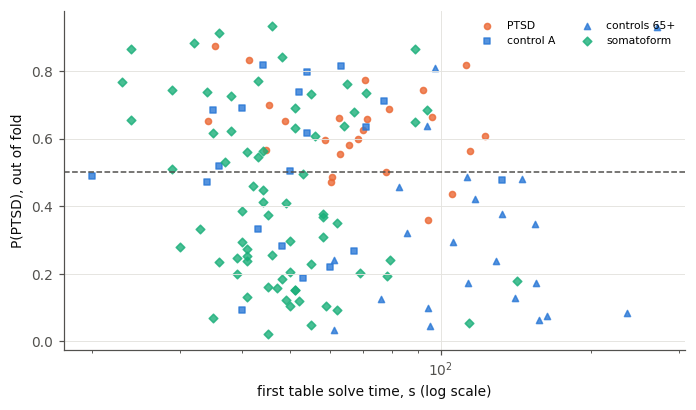

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
for s, marker in [("ptsd", "o"), ("control_A", "s"), ("control_ageing", "^"), ("somatoform", "D")]:
    m = (stratum == s) & times["trial1_s"].notna().to_numpy()
    ax.scatter(times["trial1_s"].to_numpy()[m], oof["p"].to_numpy()[m], s=16, marker=marker, color=viz.stratum_color(s),
               alpha=0.8, label=viz.STRATUM_LABELS[s])
ax.set_xscale("log")
ax.axhline(0.5, color=viz.TEXT_MUTED, ls="--", lw=1)
ax.set_xlabel("first table solve time, s (log scale)")
ax.set_ylabel("P(PTSD), out of fold")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

- Within PTSD, control A and controls 65+, P is not related to solve time. In somatoform patients the relation is weakly negative.
- Older adults are the slowest but receive low P, so the model is not measuring slowness.

## 4.7 Feature contributions

The log odds are a sum of contributions `w_j · z_j`, where z is the feature standardised on the training data. Below are the mean contributions by group and the feature medians.

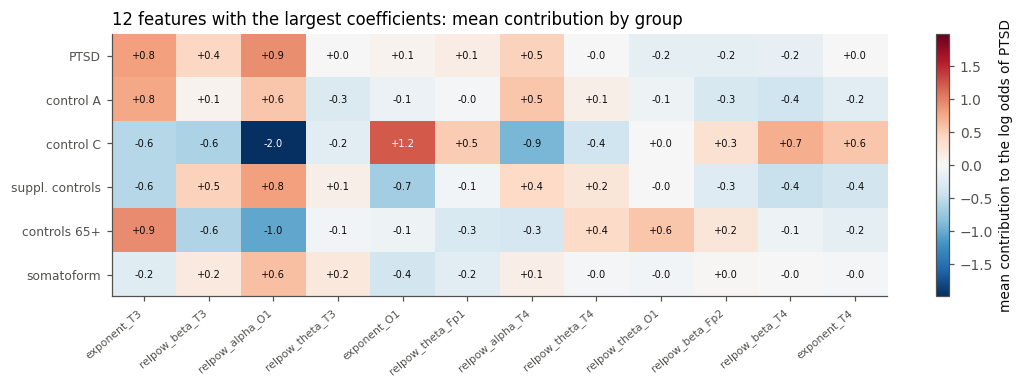

In [10]:
contrib = pd.DataFrame(confounders.feature_contributions(final, x_model), index=keys, columns=final.feature_names)
order = pd.Series(np.abs(final.coef), index=final.feature_names).sort_values(ascending=False).index[:12]
shown = [s for s in viz.STRATUM_ORDER if np.sum(stratum == s) >= 5]
mean_contrib = contrib[order].groupby(stratum).mean().reindex(shown).rename(index=viz.STRATUM_LABELS)
fig, ax = plt.subplots(figsize=(10, 3.6))
lim = float(np.nanmax(np.abs(mean_contrib.to_numpy())))
im = ax.imshow(mean_contrib.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(order)), [c.replace("rest_", "") for c in order], rotation=40, ha="right", fontsize=7)
ax.set_yticks(range(len(mean_contrib)), mean_contrib.index, fontsize=8)
ax.grid(False)
for (i, j), v in np.ndenumerate(mean_contrib.to_numpy()):
    ax.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=6.5, color="white" if abs(v) > 0.6 * lim else "#0b0b0b")
fig.colorbar(im, ax=ax, label="mean contribution to the log odds of PTSD")
ax.set_title("12 features with the largest coefficients: mean contribution by group", loc="left")
plt.tight_layout()
plt.show()

In [11]:
raw = pd.DataFrame(x_model, index=keys, columns=final.feature_names)
medians = raw[order].groupby(stratum).median().reindex(list(viz.STRATUM_ORDER)).rename(index=viz.STRATUM_LABELS).T
medians.insert(0, "coefficient", pd.Series(final.coef, index=final.feature_names)[order])
medians

,coefficient,PTSD,control A,control B,control C,suppl. controls,controls 65+,somatoform
rest_exponent_T3,-2.546,0.904,0.958,0.340,1.042,1.029,0.786,0.911
rest_relpow_beta_T3,-1.779,-0.378,-0.413,-0.275,-0.340,-0.433,-0.294,-0.383
rest_relpow_alpha_O1,1.601,-0.394,-0.385,-0.371,-0.776,-0.370,-0.649,-0.430
rest_relpow_theta_T3,1.162,-0.536,-0.564,-0.717,-0.580,-0.490,-0.536,-0.499
rest_exponent_O1,-1.121,0.716,0.783,0.285,0.180,0.979,0.628,0.861
rest_relpow_theta_Fp1,0.886,-0.401,-0.465,-0.533,-0.357,-0.455,-0.473,-0.439
rest_relpow_alpha_T4,0.862,-0.500,-0.472,-0.559,-0.734,-0.535,-0.648,-0.575
rest_relpow_theta_T4,0.839,-0.572,-0.562,-0.581,-0.652,-0.512,-0.548,-0.579
rest_relpow_theta_O1,0.777,-0.715,-0.680,-0.936,-0.695,-0.650,-0.569,-0.663
rest_relpow_beta_Fp2,0.716,-0.522,-0.501,-0.508,-0.459,-0.584,-0.424,-0.526


PTSD patients and control A receive almost the same contributions, so the model separates them poorly. Control C gets low P through its missing alpha, controls 65+ through weak alpha, and the supplementary batch through a steeper spectrum at T3 and O1.

| Feature | Lead, band | In PTSD | Reading |
| --- | --- | --- | --- |
| spectral slope | T3, 3–30 Hz | flatter than in control A | matches Kovacevic et al. (2025), but at T3 it depends strongly on the batch, the main confounding candidate |
| beta share | T3, 13–30 Hz | unchanged | a conditional effect given the slope |
| alpha share | O1, 8–13 Hz | unchanged, as in young controls | separates older adults with weak alpha, not a PTSD marker |
| theta share | Fp1, T3, T4, O1; 4–8 Hz | slightly higher | reduced vigilance and poor sleep; small effect |
| spectral slope | O1, 3–30 Hz | flatter | matches the literature, but not specific: the same happens with age |
| frontal asymmetry | Fp2 − Fp1, 8–13 Hz | unchanged | added nothing |

More detail in `docs/CLINICAL_INTERPRETATION.md`.

## 4.8 False positives among controls 65+ and somatoform patients

Difference in mean feature contributions between false positives and correctly classified subjects.

In [12]:
p = oof["p"].to_numpy()
fp_rows = {}
for s in ("control_ageing", "somatoform"):
    m = stratum == s
    fp, tn = m & (p >= 0.5), m & (p < 0.5)
    fp_rows[f"{viz.STRATUM_LABELS[s]}: false positives ({fp.sum()}) minus correct ({tn.sum()})"] = (
        contrib[fp].mean() - contrib[tn].mean())
fp_table = pd.DataFrame(fp_rows)
fp_table.loc[fp_table.abs().max(axis=1).sort_values(ascending=False).index[:8]]

,controls 65+: false positives (3) minus correct (20),somatoform: false positives (29) minus correct (45)
rest_relpow_alpha_O1,0.428,1.359
rest_relpow_alpha_T4,1.028,0.690
rest_exponent_O1,0.983,0.057
rest_exponent_T3,0.732,0.548
rest_relpow_beta_Fp2,-0.688,-0.152
rest_relpow_beta_T3,0.531,0.637
rest_relpow_theta_O1,-0.316,-0.462
rest_relpow_theta_Fp1,0.381,0.293


- Somatoform false positives have well-preserved occipital alpha: the model does not tell PTSD apart from somatoform patients with a similar resting spectrum.
- The few false positives among older adults have preserved alpha and a flatter spectrum at O1, a "younger" EEG.

## 4.9 Summary

Not explained by: export format (the model still works within format B), recording quality, age within a batch, or solve time.

Limitations:
1. Separation from young controls relies on T3 and T4.
2. Separation from control A is weak; the high AUC against all controls under 65 owes much to format C.
3. Somatoform patients are the hardest group.

Overall, the model reliably separates PTSD from normal ageing, and confounders do not explain this. Separation from young controls is weaker and depends on the temporal leads.

## 4.10 Shared clinical profile or PTSD-specific feature

The task asks for a model that responds to trauma rather than to any deviation from normal. Anxiety and depression are common in PTSD, so each feature is compared in three pairs: PTSD against young controls A and B, somatoform patients against control A (the same export format, a clean clinical comparison), and PTSD against somatoform patients. "Shared" means both clinical groups are shifted in the same direction; "specific to PTSD" means only PTSD is shifted or PTSD differs from somatoform patients. Confidence intervals come from 1000 bootstrap resamples.

In [13]:
x_df = pd.DataFrame(x_model, index=keys, columns=final.feature_names)
spec_table = confounders.disorder_specificity(x_df, stratum, ("control_A", "control_B", "control_B_supplement"))
spec_table.sort_values("verdict")

,PTSD / controls,somatoform / control A,PTSD / somatoform,"PTSD / somatoform, 95% CI",verdict
rest_relpow_theta_O1,0.428,0.522,0.435,[0.32; 0.56],no difference
rest_exponent_T3,0.398,0.550,0.425,[0.29; 0.57],no difference
rest_exponent_Fp2,0.456,0.451,0.498,[0.36; 0.63],no difference
rest_exponent_Fp1,0.505,0.454,0.538,[0.41; 0.67],no difference
rest_exponent_O1,0.377,0.554,0.399,[0.26; 0.54],no difference
rest_alpha_peak_O1,0.530,0.470,0.588,[0.46; 0.70],no difference
rest_iaf_O1,0.388,0.686,0.366,[0.22; 0.51],no difference
rest_relpow_beta_T3,0.518,0.494,0.486,[0.35; 0.63],no difference
rest_relpow_beta_Fp2,0.530,0.567,0.439,[0.31; 0.58],no difference
rest_relpow_beta_O1,0.501,0.470,0.476,[0.35; 0.61],no difference


- Only two features are reliably shifted in PTSD, and both are shared with somatoform patients: a flatter spectrum and more beta at T4. This looks like a general clinical profile of arousal.
- No feature separates PTSD specifically at the 95% level. Weak candidates are a flatter spectrum at O1, slightly more frontal theta and slower alpha compared with somatoform patients. Since PTSD and somatoform patients were exported in different formats, even these may reflect the format.

Yet somatoform patients receive lower P than control A of the same format. So the model does not separate them through the shared profile. Sex is a possible confounder, as all PTSD patients are men. The shared profile of more beta and a flatter spectrum also matches the EEG effect of benzodiazepines. These data cannot show a trauma-specific feature: there is no trauma group without PTSD, no depression or anxiety group, and no trauma-related stimuli.

## 4.11 Robustness to the recording batch

Two checks fixed in advance (`src/robustness.py`). In the first, each control group is removed from the whole procedure (selection, training and calibration) and then predicted as new data. In the second, labels are shuffled only among format B subjects and the whole nested procedure is repeated 60 times.

,n,auc_in_training,auc_unseen,auc_unseen_ci_low,auc_unseen_ci_high,share_p_ge_05_unseen
control A,20.0,0.670,0.582,0.406,0.742,0.600
control C,45.0,1.000,0.870,0.741,0.974,0.000
suppl. controls,40.0,0.828,0.693,0.557,0.816,0.375
controls 65+,23.0,0.890,0.823,0.689,0.941,0.174
somatoform,74.0,0.792,0.698,0.592,0.793,0.459


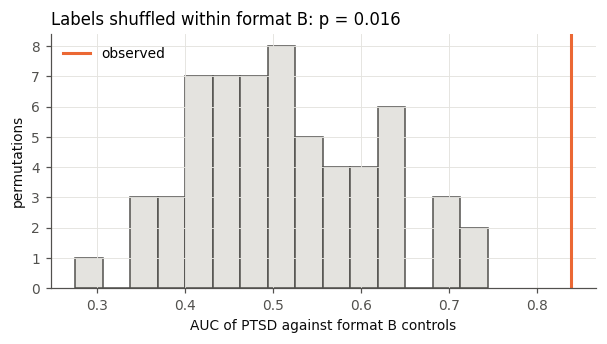

In [14]:
robust = ROOT / "results" / "validation" / "protocol8_robustness"
unseen = json.loads((robust / "unseen_batch.json").read_text(encoding="utf-8"))
display(pd.DataFrame(unseen).T.rename(index=viz.STRATUM_LABELS)[
    ["n", "auc_in_training", "auc_unseen", "auc_unseen_ci_low", "auc_unseen_ci_high", "share_p_ge_05_unseen"]])
perm = json.loads((robust / "permutation_within_format_b.json").read_text(encoding="utf-8"))
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.hist(perm["null_auc"], bins=15, color=viz.GRID, edgecolor=viz.TEXT_MUTED)
ax.axvline(perm["observed_auc"], color=viz.COHORT_COLORS[config.GROUP_PTSD], lw=2, label="observed")
ax.set_xlabel("AUC of PTSD against format B controls")
ax.set_ylabel("permutations")
ax.set_title(f"Labels shuffled within format B: p = {perm['p_value']:.3f}", loc="left")
ax.legend()
plt.show()

- A control group the procedure has never seen is separated less well, by about 0.1 in AUC. Older adults keep the best separation, control A the worst.
- None of the 60 shuffled runs reached the observed AUC within format B. Separation inside one export format is not an artefact of the selection procedure.

## 4.12 Clinical interpretation

- PTSD patients and controls differ in more than the diagnosis: combat trauma, head injury, medication and sleep. P is similarity to the EEG of the clinical cohort, not the probability of trauma in a person.
- Occipital alpha is not reduced in PTSD; the effect expected from the literature is absent in these data.
- The spectrum at O1 is slightly flatter and frontal theta slightly higher in PTSD. This fits arousal and poor sleep, but the effects are small and not specific.
- Muscle tension on the temporal leads is not supported: high-frequency power at T3 and T4 in PTSD matches control A and somatoform patients.
- Somatoform patients are clinically the closest group, and most PTSD differences from controls are present in them too (section 4.10).
- Specificity varies a lot between batches of young controls. If one person in ten had PTSD, about a quarter of positive results would be correct. The model is not a diagnostic tool.
- In the Schulte tables PTSD patients work uniformly slower, with normal warm-up and no fatigue towards the end.

More detail in `docs/CLINICAL_INTERPRETATION.md`.